In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load data
df = pd.read_csv('../data/new_regular_salary.csv', encoding='latin1')

# Requested predictors and target
#x_cols = ['GS', 'MP', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PTS', 'Awards']
#x_cols = ['GS',  'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PTS', 'Awards']
x_cols = [ 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PTS', 'Awards']
y_col = 'Salary'

# Prepare data - keep only needed columns and convert to numeric
model_df = df[x_cols + [y_col]].copy()
model_df = model_df.apply(pd.to_numeric, errors='coerce').dropna()

# Convert salary to millions
model_df['Salary in million'] = model_df[y_col] / 1_000_000

X = model_df[x_cols]
y = model_df['Salary in million']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Evaluate model
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Random Forest Regression Results")
print("=" * 50)
print(f"Train R² Score: {train_r2:.4f}")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Train Mean Squared Error: {train_mse:.4f}")
print(f"Test Mean Squared Error: {test_mse:.4f}")
print(f"Train Mean Absolute Error: {train_mae:.4f}")
print(f"Test Mean Absolute Error: {test_mae:.4f}")
print("\nFeature Importance:")
print("-" * 50)
for col, importance in sorted(zip(x_cols, rf_model.feature_importances_), key=lambda x: x[1], reverse=True):
    print(f"{col}: {importance:.4f}")

Random Forest Regression Results
Train R² Score: 0.9528
Test R² Score: 0.6606
Train Mean Squared Error: 10.7757
Test Mean Squared Error: 55.1626
Train Mean Absolute Error: 2.6162
Test Mean Absolute Error: 5.0373

Feature Importance:
--------------------------------------------------
PTS: 0.6827
TRB: 0.0786
AST: 0.0628
STL: 0.0557
TOV: 0.0514
BLK: 0.0419
Awards: 0.0269


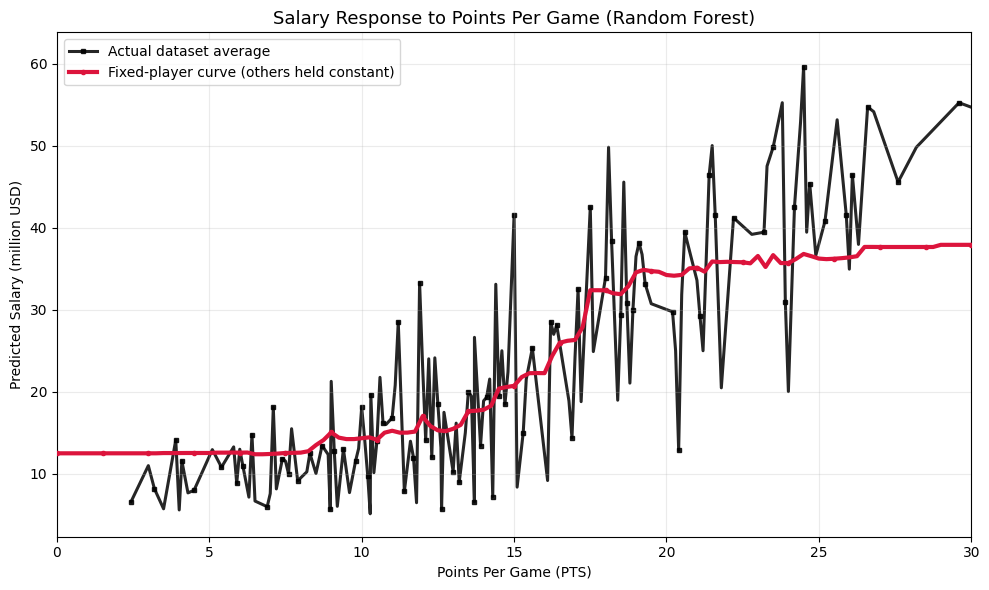

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_name = 'PTS'
if feature_name not in X.columns:
    raise ValueError(f"'{feature_name}' is not in model features: {list(X.columns)}")

# Counterfactual curve: hold all other features fixed and sweep PTS from 0 to 30
pts_grid = np.linspace(0, 30, 121)
baseline_player = X.median(numeric_only=True)
scenario_df = pd.DataFrame([baseline_player.values] * len(pts_grid), columns=X.columns)
scenario_df[feature_name] = pts_grid
scenario_df = scenario_df[X.columns]
counterfactual_salary = rf_model.predict(scenario_df)

# Actual dataset curve: average observed salary at each PTS value in the data
actual_curve = (
    model_df.groupby(feature_name, as_index=False)['Salary in million']
    .mean()
    .sort_values(feature_name)
)

fig, ax = plt.subplots(figsize=(10, 6))

# Actual observed relationship from the dataset
ax.plot(
    actual_curve[feature_name],
    actual_curve['Salary in million'],
    color='black',
    linewidth=2.2,
    alpha=0.85,
    marker='s',
    markersize=3,
    markevery=2,
    zorder=1,
    label='Actual dataset average',
)

# Draw counterfactual on top
ax.plot(
    pts_grid,
    counterfactual_salary,
    color='crimson',
    linewidth=3,
    marker='o',
    markersize=3,
    markevery=6,
    zorder=5,
    label='Fixed-player curve (others held constant)',
)

ax.set_xlim(0, 30)
ax.set_title('Salary Response to Points Per Game (Random Forest)', fontsize=13)
ax.set_xlabel('Points Per Game (PTS)')
ax.set_ylabel('Predicted Salary (million USD)')
ax.legend(frameon=True)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

required_features = ['TRB', 'AST', 'STL', 'BLK', 'TOV', 'PTS', 'Awards']

if 'rf_model' not in globals():
    raise ValueError("rf_model is not defined. Run Cell 1 first to train the Random Forest model.")
if 'x_cols' not in globals():
    raise ValueError("x_cols is not defined. Run Cell 1 first.")

missing_features = [f for f in required_features if f not in x_cols]
if missing_features:
    raise ValueError(f"These required features are not in x_cols: {missing_features}")

# Show feature importance from the trained Random Forest
importance_df = pd.DataFrame({
    'Feature': x_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('Feature importance (highest to lowest):')
print(importance_df.to_string(index=False))

def predict_salary(trb, ast, stl, blk, tov, pts, awards):
    input_dict = {
        'TRB': float(trb),
        'AST': float(ast),
        'STL': float(stl),
        'BLK': float(blk),
        'TOV': float(tov),
        'PTS': float(pts),
        'Awards': float(awards),
    }
    input_row = pd.DataFrame([[input_dict[f] for f in x_cols]], columns=x_cols)
    pred_salary_million = rf_model.predict(input_row)[0]
    pred_salary_usd = pred_salary_million * 1_000_000
    return pred_salary_million, pred_salary_usd

# Edit these values directly, then run this cell
player_stats = {
    'PTS': 15.1,
    'AST': 1.3,
    'TRB': 13.7,
    'STL': 0.8,
    'BLK': 2,
    'TOV': 1.9,
    'Awards': 1,
}

pred_million, pred_usd = predict_salary(
    player_stats['TRB'],
    player_stats['AST'],
    player_stats['STL'],
    player_stats['BLK'],
    player_stats['TOV'],
    player_stats['PTS'],
    player_stats['Awards'],
)

display_stats = {
    'Points': player_stats['PTS'],
    'Assist': player_stats['AST'],
    'Rebound': player_stats['TRB'],
    'Steal': player_stats['STL'],
    'Block': player_stats['BLK'],
    'Turnover': player_stats['TOV'],
    'Awards': player_stats['Awards'],
}

print('\nInput stats:')
print(display_stats)
print(f"\nPredicted Salary: ${pred_usd:,.0f}")
print(f"Predicted Salary (million USD): {pred_million:.3f}")

Feature importance (highest to lowest):
Feature  Importance
    PTS    0.682710
    TRB    0.078645
    AST    0.062772
    STL    0.055682
    TOV    0.051353
    BLK    0.041918
 Awards    0.026920

Input stats:
{'Points': 15.1, 'Assist': 1.3, 'Rebound': 13.7, 'Steal': 0.8, 'Block': 2, 'Turnover': 1.9, 'Awards': 1}

Predicted Salary: $32,010,118
Predicted Salary (million USD): 32.010


In [9]:
pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------- ----------------- 524.3/914.9 kB 1.6 MB/s eta 0:00:01
   ---------------------------------- ----- 786.4/914.9 kB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 1.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.2 MB 2.2 MB/s eta 0:00:01
   ------------------- -------------------- 1.0/2.2 MB 2.0 MB/s eta 0:00:01
   --------------------------------- ------ 1.8/2.2 MB 2.3 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 2.4 MB/s  0:00:00

   ------------- -------------------------- 1/3 [jupyterlab_widgets]

Note: you may need to restart the

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\ricky\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\share\\jupyter\\labextensions\\@jupyter-widgets\\jupyterlab-manager\\static\\packages_base_lib_index_js-webpack_sharing_consume_default_jquery_jquery.5dd13f8e980fa3c50bfe.js'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ricky\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Old data


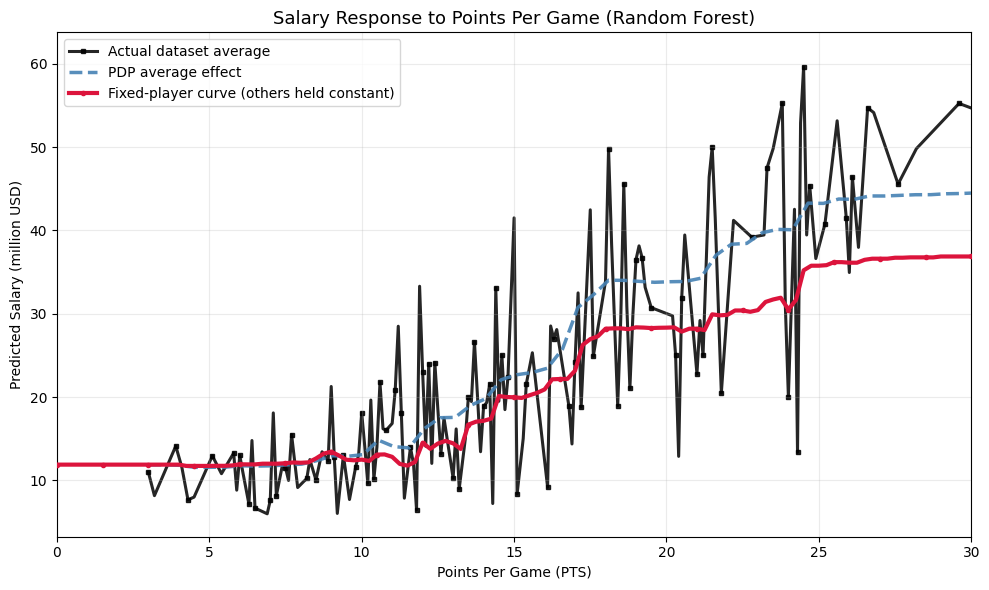

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import partial_dependence

feature_name = 'PTS'
if feature_name not in X.columns:
    raise ValueError(f"'{feature_name}' is not in model features: {list(X.columns)}")

# PDP (average effect): model response averaged over the observed distribution of other features
pd_result = partial_dependence(
    estimator=rf_model,
    X=X,
    features=[feature_name],
    grid_resolution=60,
    percentiles=(0.0, 1.0),
)

pdp_x = pd_result['grid_values'][0]
pdp_y = pd_result['average'][0]

# Counterfactual curve: hold all other features fixed and sweep PTS from 0 to 30
pts_grid = np.linspace(0, 30, 121)
baseline_player = X.median(numeric_only=True)
scenario_df = pd.DataFrame([baseline_player.values] * len(pts_grid), columns=X.columns)
scenario_df[feature_name] = pts_grid
scenario_df = scenario_df[X.columns]
counterfactual_salary = rf_model.predict(scenario_df)

# Actual dataset curve: average observed salary at each PTS value in the data
actual_curve = (
    model_df.groupby(feature_name, as_index=False)['Salary in million']
    .mean()
    .sort_values(feature_name)
)

fig, ax = plt.subplots(figsize=(10, 6))

# Actual observed relationship from the dataset
ax.plot(
    actual_curve[feature_name],
    actual_curve['Salary in million'],
    color='black',
    linewidth=2.2,
    alpha=0.85,
    marker='s',
    markersize=3,
    markevery=2,
    zorder=1,
    label='Actual dataset average',
)

# Draw PDP second
ax.plot(
    pdp_x,
    pdp_y,
    color='steelblue',
    linestyle='--',
    linewidth=2.5,
    alpha=0.9,
    zorder=3,
    label='PDP average effect',
)

# Draw counterfactual on top
ax.plot(
    pts_grid,
    counterfactual_salary,
    color='crimson',
    linewidth=3,
    marker='o',
    markersize=3,
    markevery=6,
    zorder=5,
    label='Fixed-player curve (others held constant)',
)

ax.set_xlim(0, 30)
ax.set_title('Salary Response to Points Per Game (Random Forest)', fontsize=13)
ax.set_xlabel('Points Per Game (PTS)')
ax.set_ylabel('Predicted Salary (million USD)')
ax.legend(frameon=True)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8068      3.745     -0.750      0.454     -10.187       4.574
GS             0.0645      0.034      1.890      0.060      -0.003       0.132
MP            -0.3079      0.215     -1.431      0.154      -0.732       0.116
TRB            0.1146      0.397      0.289      0.773      -0.667       0.896
AST            1.3747      0.618      2.226      0.027       0.157       2.592
STL            3.7031      1.832      2.022      0.044       0.093       7.314
BLK            3.2676      1.817      1.798      0.074      -0.314       6.850
TOV           -1.8020      1.425     -1.264      0.208      -4.611       1.007
PTS            1.5542      0.201      7.717      0.000       1.157       1.951
Awards         5.6801      1.908      2.976      0.003       1.919       9.441
Pos_C          1.0775      3.131      0.344      0.731      -5.093       7.248